PHẦN 1: TỔNG QUAN TÌNH HÌNH TRỄ CHUYẾN BAY (2021–2025)

Phân tích tổng quan tình trạng trễ chuyến bay trong tháng 1 giai đoạn 2021–2025, bao gồm:
- Số lượng và tỷ lệ chuyến bay bị trễ
- Mức độ trễ (trung bình và trung vị)
- Phân bố mức độ nghiêm trọng của trễ chuyến
- Lan truyền trễ giữa độ trể khởi hành và độ trễ đến nơi

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

os.makedirs("delay_analysis", exist_ok=True)

df = pd.read_parquet("flights_2021_2025.parquet")

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])
df["YEAR"] = df["FL_DATE"].dt.year

df_delay = df[df["ARR_DELAY_NEW"] > 0].copy()

print(f"Tổng chuyến bay: {len(df)}")
print(f"Chuyến bay bị trễ: {len(df_delay)}")

Tổng chuyến bay: 2525185
Chuyến bay bị trễ: 829879


1. Số lượng và tỷ lệ chuyến bay bị trễ

In [3]:
total = df.groupby("YEAR").size()
delay = df_delay.groupby("YEAR").size()

rate = (delay / total * 100).round(2)

table1 = pd.DataFrame({
    "Tổng chuyến": total,
    "Chuyến trễ": delay,
    "Tỷ lệ trễ (%)": rate
})

table1

,Tổng chuyến,Chuyến trễ,Tỷ lệ trễ (%)
YEAR,,,
2021,361428,78764,21.79
2022,537902,167007,31.05
2023,538837,202575,37.59
2024,547271,209400,38.26
2025,539747,172133,31.89


<Figure size 1000x600 with 0 Axes>

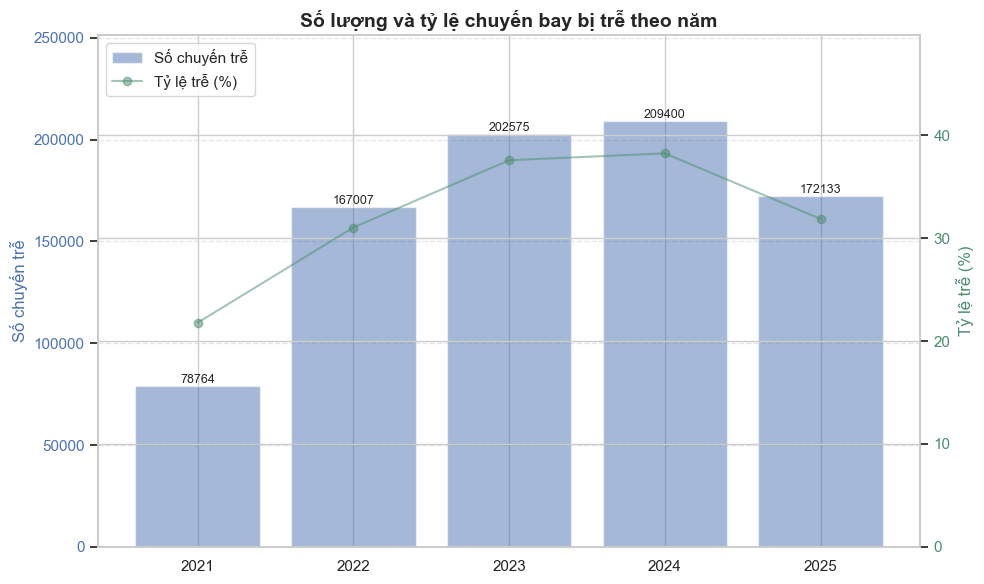

In [4]:
plt.figure(figsize=(10,6))
fig, ax1 = plt.subplots(figsize=(10,6))

bar_color = "#4C72B0"   
line_color = "#4B8D6E"  

bars = ax1.bar(
    table1.index,
    table1["Chuyến trễ"],
    color=bar_color,
    alpha=0.5,
    label="Số chuyến trễ"
)
ax1.set_ylabel("Số chuyến trễ", color=bar_color)
ax1.tick_params(axis='y', labelcolor=bar_color)
for x, y in zip(table1.index, table1["Chuyến trễ"]):
    ax1.text(x, y, f"{int(y)}", ha='center', va='bottom', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(
    table1.index,
    table1["Tỷ lệ trễ (%)"],
    color=line_color,
    marker='o',
    linewidth=1.5,
    markersize=6,
    alpha=0.5,
    label="Tỷ lệ trễ (%)"
)

ax2.set_ylabel("Tỷ lệ trễ (%)", color=line_color)
ax2.tick_params(axis='y', labelcolor=line_color)

ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.title("Số lượng và tỷ lệ chuyến bay bị trễ theo năm", fontsize=14, weight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.set_ylim(0, table1["Chuyến trễ"].max() * 1.2)
ax2.set_ylim(0, table1["Tỷ lệ trễ (%)"].max() * 1.3)

plt.tight_layout()
plt.savefig("delay_analysis/overview_delay.png", dpi=300)
plt.show()

2. Mức độ trễ (trung bình và trung vị)

In [5]:
table2 = df_delay.groupby("YEAR").agg({
    "ARR_DELAY_NEW": [
        "mean",
        "median"
    ]
})

table2.columns = ["Trung bình", "Trung vị"]
table2 = table2.astype(float).round(2)


table2

,Trung bình,Trung vị
YEAR,,
2021,32.42,12.0
2022,42.50,19.0
2023,42.78,19.0
2024,48.17,21.0
2025,43.14,18.0


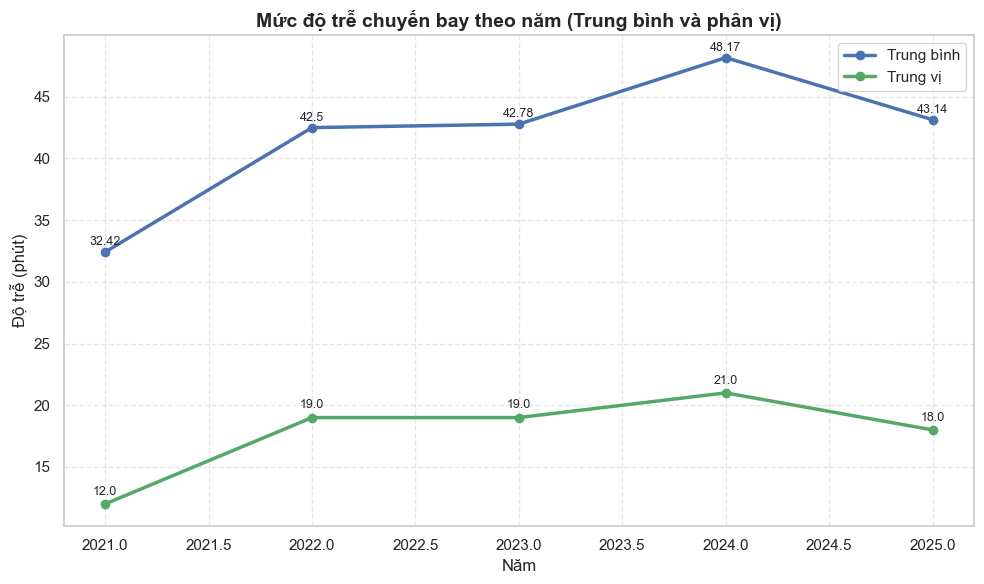

In [6]:
plt.figure(figsize=(10,6))

colors = {
    "Trung bình": "#4C72B0",
    "Trung vị": "#55A868",
}

for col in table2.columns:
    plt.plot(
        table2.index,
        table2[col],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=col,
        color=colors[col]
    )

for x, y in zip(table2.index, table2["Trung bình"]):
    plt.text(x, y + 0.3, f"{y}", ha='center', va='bottom', fontsize=9)

for x, y in zip(table2.index, table2["Trung vị"]):
    plt.text(x, y + 0.5, f"{y}", ha='center', va='bottom', fontsize=9)

plt.title("Mức độ trễ chuyến bay theo năm (Trung bình và phân vị)", fontsize=14, weight='bold')
plt.xlabel("Năm")
plt.ylabel("Độ trễ (phút)")

plt.grid(linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("delay_analysis/muc_do_tre_percentile.png", dpi=300)
plt.show()

3. Phân bố mức độ nghiêm trọng

In [7]:
def classify_delay(x):
    if x <= 45:
        return "Nhẹ (15–45)"
    elif x <= 120:
        return "Trung bình (45–120)"
    else:
        return "Nặng (>120)"

df_delay["Mức độ trễ"] = df_delay["ARR_DELAY_NEW"].apply(classify_delay)

severity = df_delay.groupby(["YEAR", "Mức độ trễ"]).size().unstack().fillna(0)

severity_pct = (severity.div(severity.sum(axis=1), axis=0) * 100).round(2)

severity_pct

Mức độ trễ,Nhẹ (15–45),Nặng (>120),Trung bình (45–120)
YEAR,,,
2021,83.28,5.26,11.45
2022,73.28,7.60,19.11
2023,73.99,7.89,18.11
2024,71.62,9.32,19.06
2025,74.78,7.74,17.48


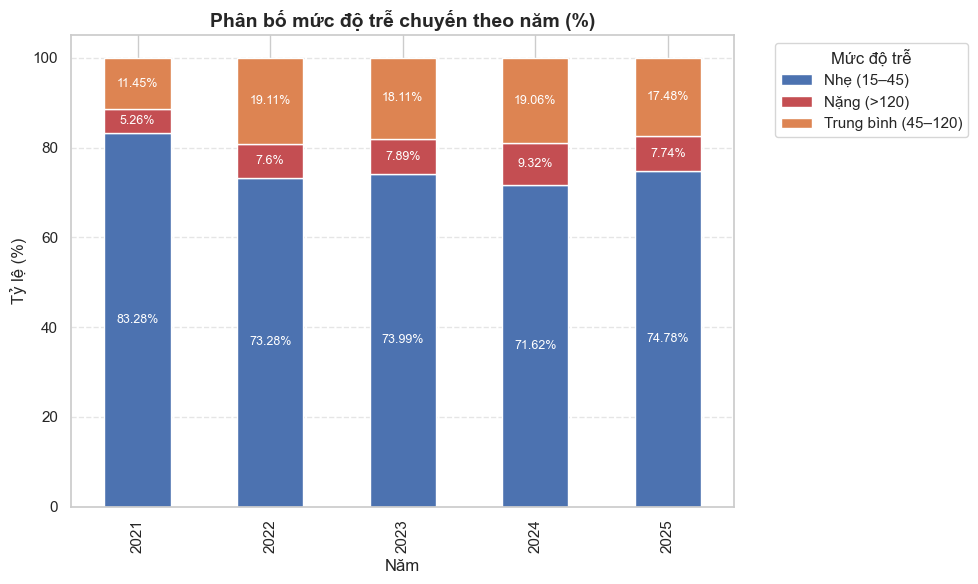

In [8]:
colors = ["#4C72B0", "#C44E52", "#DD8452"]  

ax = severity_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=colors
)

for i in range(len(severity_pct)):
    cumulative = 0
    for j, col in enumerate(severity_pct.columns):
        val = severity_pct.iloc[i, j]
        if val > 5:
            ax.text(
                i,
                cumulative + val/2,
                f"{val}%",
                ha='center',
                va='center',
                fontsize=9,
                color="white"
            )
        cumulative += val

plt.title("Phân bố mức độ trễ chuyến theo năm (%)", fontsize=14, weight='bold')
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ (%)")

plt.legend(title="Mức độ trễ", bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("delay_analysis/phan_bo_muc_do_tre.png", dpi=300)
plt.show()

4. Lan truyền trễ

In [9]:
df_delay["IS_CASCADE"] = df_delay["ARR_DELAY_NEW"] > df_delay["DEP_DELAY_NEW"]

cascade_rate = df_delay["IS_CASCADE"].mean() * 100
print(f"Tỷ lệ lan truyền trễ: {cascade_rate:.2f}%")

Tỷ lệ lan truyền trễ: 55.10%


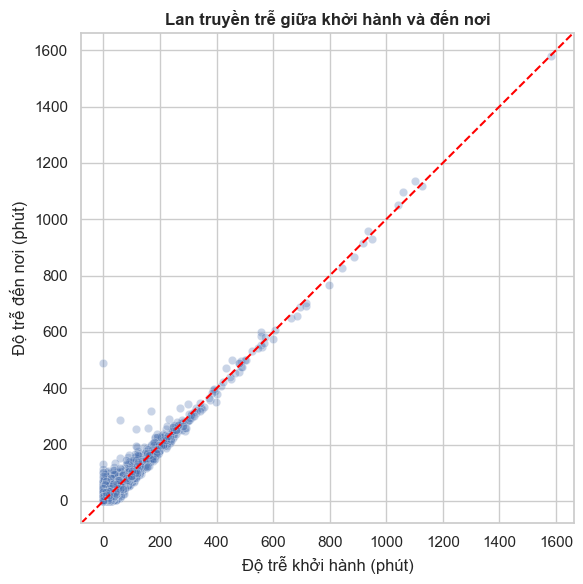

In [10]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    data=df_delay.sample(5000),
    x="DEP_DELAY_NEW",
    y="ARR_DELAY_NEW",
    alpha=0.3
)

plt.axline((0,0), slope=1, linestyle='--', color='red')

plt.title("Lan truyền trễ giữa khởi hành và đến nơi", weight='bold')
plt.xlabel("Độ trễ khởi hành (phút)")
plt.ylabel("Độ trễ đến nơi (phút)")

plt.tight_layout()
plt.savefig("delay_analysis/cascade.png", dpi=300)
plt.show()

PHẦN 2: PHÂN TÍCH THEO THỜI GIAN

Phân tích sự biến động của độ trễ chuyến bay theo:
- Giờ khởi hành
- Ngày trong tuần
- Giờ và ngày trong tuần

1. Theo giờ khởi hành

In [54]:
df_delay["GIỜ KHỞI HÀNH"] = df_delay["CRS_DEP_TIME"] // 100

table_hour = df_delay.groupby(["YEAR", "GIỜ KHỞI HÀNH"])["ARR_DELAY_NEW"].mean().reset_index()

table_hour.rename(columns={
    "ARR_DELAY_NEW": "Độ trễ trung bình (phút)",
}, inplace=True)

table_hour["Độ trễ trung bình (phút)"] = table_hour["Độ trễ trung bình (phút)"].astype(float).round(2)

table_hour.head()

,YEAR,GIỜ KHỞI HÀNH,Độ trễ trung bình (phút)
0,2021,0,30.15
1,2021,1,38.54
2,2021,3,10.50
3,2021,4,15.00
4,2021,5,36.12


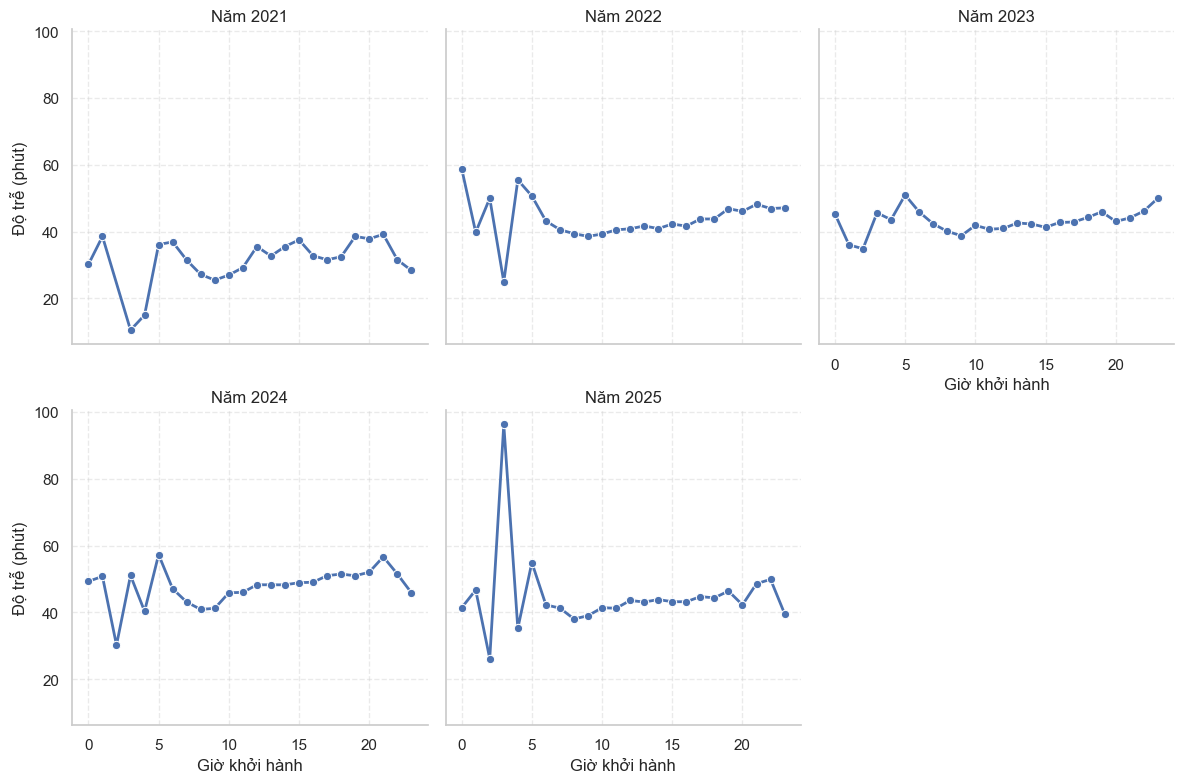

In [12]:
g = sns.FacetGrid(
    table_hour,
    col="YEAR",
    col_wrap=3,
    height=4,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="GIỜ KHỞI HÀNH",
    y="Độ trễ trung bình (phút)",
    marker="o",
    linewidth=2
)

g.set_titles("Năm {col_name}")
g.set_axis_labels("Giờ khởi hành", "Độ trễ (phút)")

for ax in g.axes.flatten():
    ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("delay_analysis/delay_theo_gio_khoi_hanh.png", dpi=300)
plt.show()

2. Theo ngày trong tuần

In [13]:
table_dow = df_delay.groupby(["YEAR", "DAY_OF_WEEK"])["ARR_DELAY_NEW"].mean().unstack()

thu_map = {
    0: "Thứ 2", 1: "Thứ 3", 2: "Thứ 4",
    3: "Thứ 5", 4: "Thứ 6", 5: "Thứ 7", 6: "Chủ nhật"
}

table_dow.columns = [thu_map[i] for i in table_dow.columns]

table_dow

,Thứ 2,Thứ 3,Thứ 4,Thứ 5,Thứ 6,Thứ 7,Chủ nhật
YEAR,,,,,,,
2021,36.789898,26.727530,30.334373,28.386686,32.600506,33.922085,33.523624
2022,44.131710,40.095917,38.594364,38.645859,41.132740,44.590961,46.146484
2023,46.715363,45.465164,61.447636,36.199898,31.430723,33.110737,38.421528
2024,57.536579,58.807999,39.945290,36.733032,49.335602,44.531178,44.955433
2025,47.667267,38.985611,36.234058,39.845085,45.353645,44.020023,47.121502


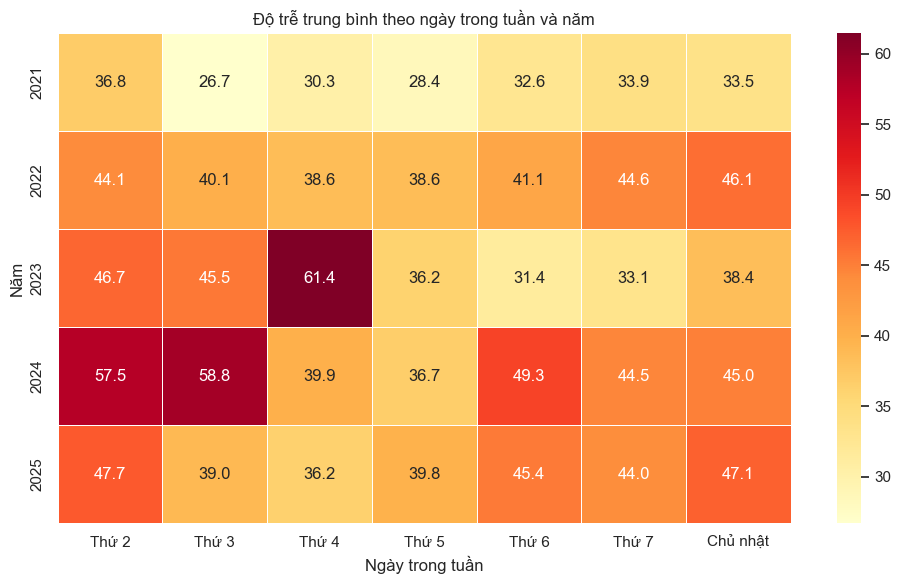

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(
    table_dow,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Độ trễ trung bình theo ngày trong tuần và năm")
plt.xlabel("Ngày trong tuần")
plt.ylabel("Năm")

plt.tight_layout()
plt.savefig("delay_analysis/delay_ngay_trong_tuan.png", dpi=300)
plt.show()

3. Theo giờ và thứ

In [15]:
pivot_gio_thu = df_delay.pivot_table(
    index="DAY_OF_WEEK",
    columns="GIỜ KHỞI HÀNH",
    values="ARR_DELAY_NEW",
    aggfunc="mean"
)

pivot_gio_thu = pivot_gio_thu.astype(float).round(2)

# đổi tên thứ
pivot_gio_thu.index = [thu_map[i] for i in pivot_gio_thu.index]

pivot_gio_thu.head()

GIỜ KHỞI HÀNH,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Thứ 2,43.12,55.59,37.84,39.54,71.92,53.57,46.15,40.96,40.12,39.49,...,49.59,49.96,48.93,51.76,52.05,55.08,52.35,55.18,58.26,52.67
Thứ 3,51.14,53.34,44.97,51.38,41.10,52.00,45.72,43.83,40.40,38.93,...,46.62,46.41,46.94,48.41,48.37,52.63,48.84,55.00,52.04,50.28
Thứ 4,67.92,49.67,57.43,32.17,59.75,69.27,56.19,47.37,41.83,41.63,...,43.67,43.03,42.69,42.66,42.23,45.69,39.27,41.26,42.49,44.62
Thứ 5,57.41,30.03,22.85,40.16,41.50,42.91,36.43,33.91,33.42,33.11,...,36.01,37.18,37.92,37.87,40.40,39.16,38.61,43.26,42.55,36.35
Thứ 6,36.08,26.10,44.35,17.95,28.33,48.86,41.74,42.11,38.35,37.81,...,41.71,40.24,41.41,43.37,42.33,43.04,43.23,46.48,42.12,36.04


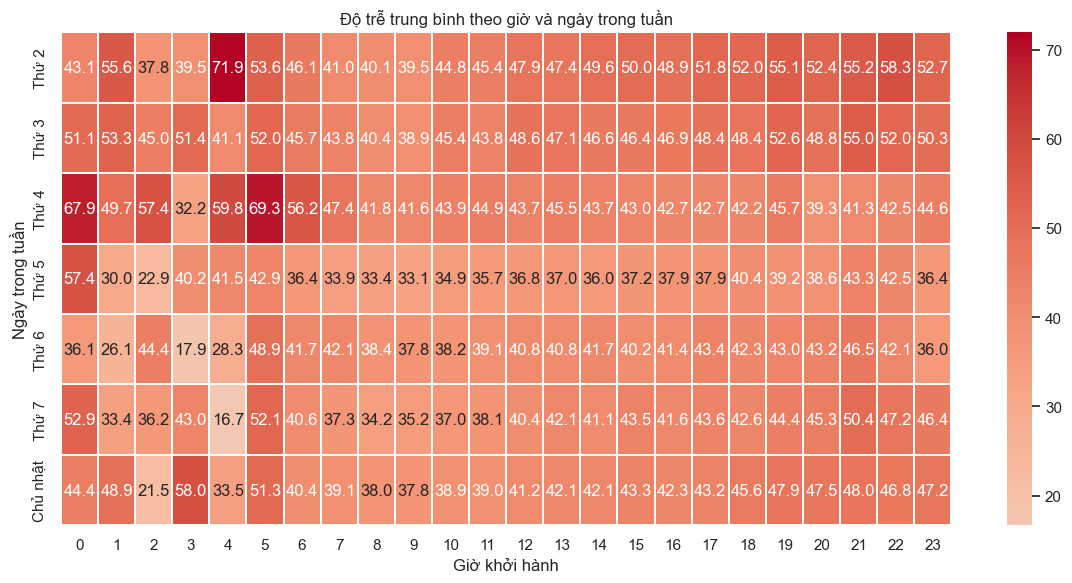

In [16]:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_gio_thu,
    annot=True,
    cmap="coolwarm",
    fmt=".1f",
    center=0,
    linewidths=0.3,
    linecolor="white"
)

plt.title("Độ trễ trung bình theo giờ và ngày trong tuần")
plt.xlabel("Giờ khởi hành")
plt.ylabel("Ngày trong tuần")

plt.tight_layout()
plt.savefig("delay_analysis/delay_gio_thu.png", dpi=300)
plt.show()

PHẦN 3: PHÂN TÍCH THEO THỰC THỂ

Phân tích sự biến động của độ trễ chuyến bay theo:
- Hãng bay
- Sân bay
- Khoảng cách

1. Theo hãng bay

In [17]:
carrier_table = df_delay.groupby("OP_UNIQUE_CARRIER")["ARR_DELAY_NEW"].mean().reset_index()

carrier_table.rename(columns={
    "OP_UNIQUE_CARRIER": "Hãng bay",
    "ARR_DELAY_NEW": "Độ trễ trung bình (phút)"
}, inplace=True)

# lấy top 10
carrier_top10 = carrier_table.sort_values(
    "Độ trễ trung bình (phút)", ascending=False
).head(10)

carrier_top10

,Hãng bay,Độ trễ trung bình (phút)
6,G4,53.748352
11,OO,53.563831
10,OH,52.975964
5,F9,52.369595
0,9E,51.598289
15,YV,50.901382
3,B6,50.371696
1,AA,49.662182
13,UA,43.539051
4,DL,42.850624


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18636\1856531050.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


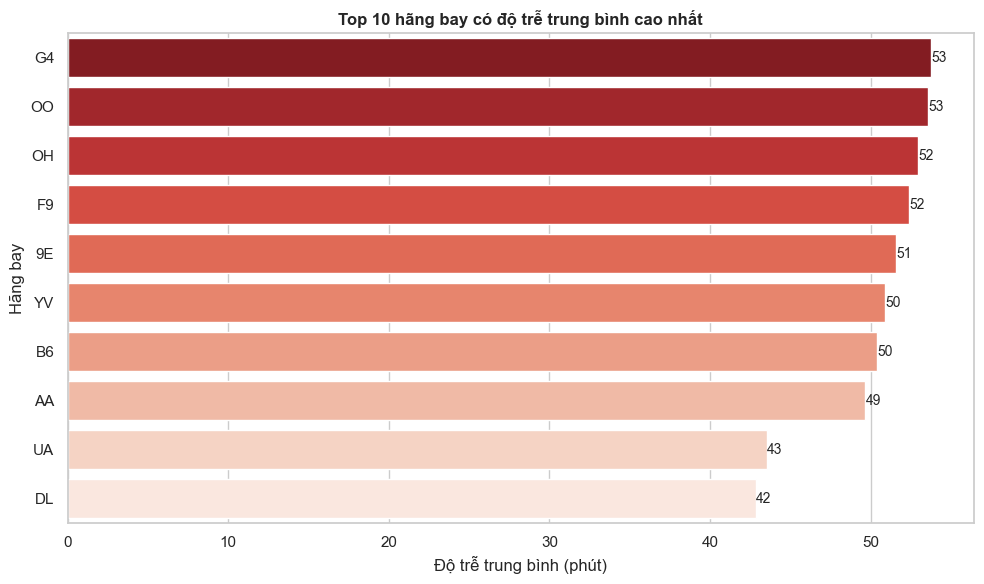

In [18]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=carrier_top10,
    x="Độ trễ trung bình (phút)",
    y="Hãng bay",
    palette="Reds_r"
)

for i, v in enumerate(carrier_top10["Độ trễ trung bình (phút)"]):
    ax.text(v + 0.5, i, f"{int(v)}", ha='center', va='center', fontsize=10)

plt.title("Top 10 hãng bay có độ trễ trung bình cao nhất", weight='bold')
plt.xlabel("Độ trễ trung bình (phút)")
plt.ylabel("Hãng bay")

plt.tight_layout()
plt.savefig("delay_analysis/carrier_top10.png", dpi=300)
plt.show()

In [19]:
carrier_year = df_delay.groupby(
    ["YEAR", "OP_UNIQUE_CARRIER"]
)["ARR_DELAY_NEW"].mean().reset_index()

top_carriers = carrier_top10["Hãng bay"]

carrier_year = carrier_year[
    carrier_year["OP_UNIQUE_CARRIER"].isin(top_carriers)
]

carrier_year["ARR_DELAY_NEW"] = carrier_year["ARR_DELAY_NEW"].astype(float).round(2)

carrier_year.rename(columns={
    "YEAR": "Năm",
    "OP_UNIQUE_CARRIER": "Hãng bay",
    "ARR_DELAY_NEW": "Độ trễ trung bình"
}, inplace=True)

carrier_year.head()

,Năm,Hãng bay,Độ trễ trung bình
0,2021,9E,41.02
1,2021,AA,37.62
3,2021,B6,30.73
4,2021,DL,30.83
5,2021,F9,26.37


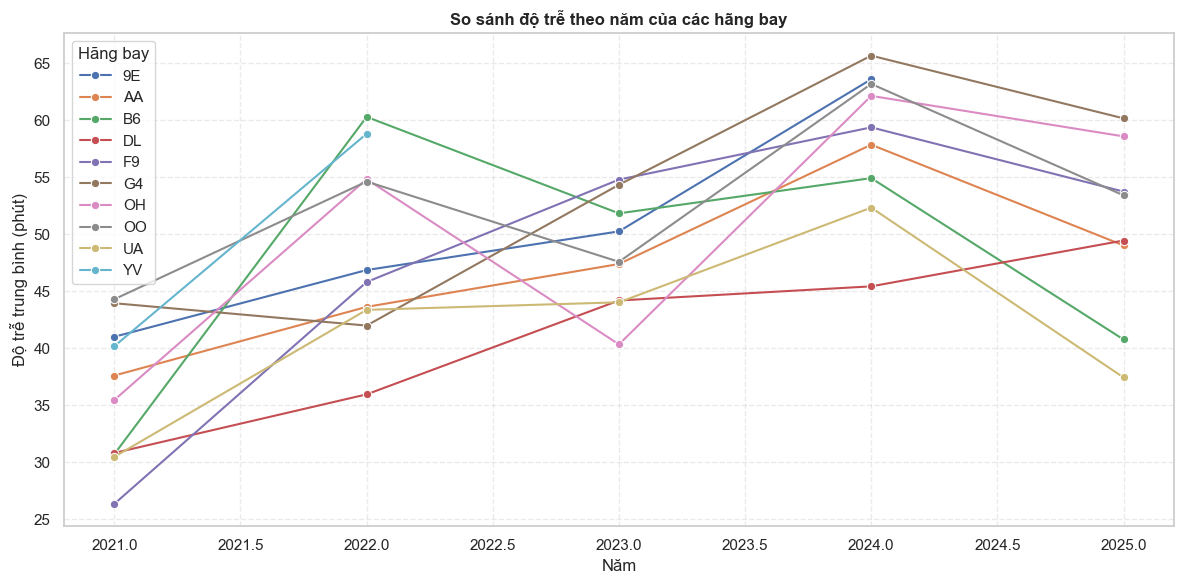

In [20]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=carrier_year,
    x="Năm",
    y="Độ trễ trung bình",
    hue="Hãng bay",
    marker="o"
)

plt.title("So sánh độ trễ theo năm của các hãng bay", weight='bold')
plt.xlabel("Năm")
plt.ylabel("Độ trễ trung bình (phút)")

plt.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("delay_analysis/carrier_year.png", dpi=300)
plt.show()

2. Theo sân bay

In [21]:
origin_dep = df_delay.groupby("ORIGIN")["DEP_DELAY_NEW"].mean().reset_index()

origin_dep.rename(columns={
    "ORIGIN": "Sân bay đi",
    "DEP_DELAY_NEW": "Độ trễ khởi hành TB (phút)"
}, inplace=True)

origin_dep["Độ trễ khởi hành TB (phút)"] = origin_dep["Độ trễ khởi hành TB (phút)"].astype(float).round(2)

origin_dep_top15 = origin_dep.sort_values(
    "Độ trễ khởi hành TB (phút)", ascending=False
).head(15)

origin_dep_top15

,Sân bay đi,Độ trễ khởi hành TB (phút)
77,CNY,166.38
64,CGI,150.67
157,HOB,139.92
218,MEI,128.52
174,INL,123.71
263,PGV,123.00
246,OGS,122.56
148,GTR,117.84
359,VCT,112.76
295,RIW,108.10


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18636\2199951119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


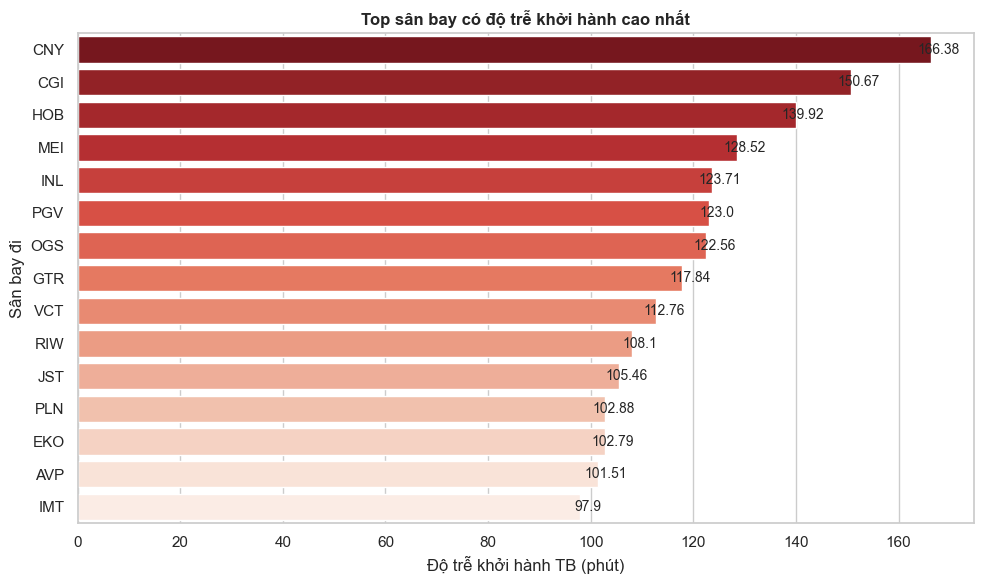

In [22]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=origin_dep_top15,
    x="Độ trễ khởi hành TB (phút)",
    y="Sân bay đi",
    palette="Reds_r"
)

for i, v in enumerate(origin_dep_top15["Độ trễ khởi hành TB (phút)"]):
    ax.text(v + 1.5, i, f"{v}", ha='center', va='center', fontsize=10)

plt.title("Top sân bay có độ trễ khởi hành cao nhất", weight='bold')

plt.tight_layout()
plt.savefig("delay_analysis/origin_dep_delay.png", dpi=300)
plt.show()

In [23]:
dest_arr = df_delay.groupby("DEST")["ARR_DELAY_NEW"].mean().reset_index()

dest_arr.rename(columns={
    "DEST": "Sân bay đến",
    "ARR_DELAY_NEW": "Độ trễ đến TB (phút)"
}, inplace=True)

dest_arr["Độ trễ đến TB (phút)"] = dest_arr["Độ trễ đến TB (phút)"].astype(float).round(2)

dest_arr_top15 = dest_arr.sort_values(
    "Độ trễ đến TB (phút)", ascending=False
).head(15)

dest_arr_top15

,Sân bay đến,Độ trễ đến TB (phút)
224,MGW,142.38
183,JLN,103.74
16,ALS,101.92
186,JST,97.95
360,VCT,93.33
4,ABY,92.49
71,CKB,91.85
296,RIW,90.37
278,PRC,88.93
269,PIB,87.17


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18636\1017273223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


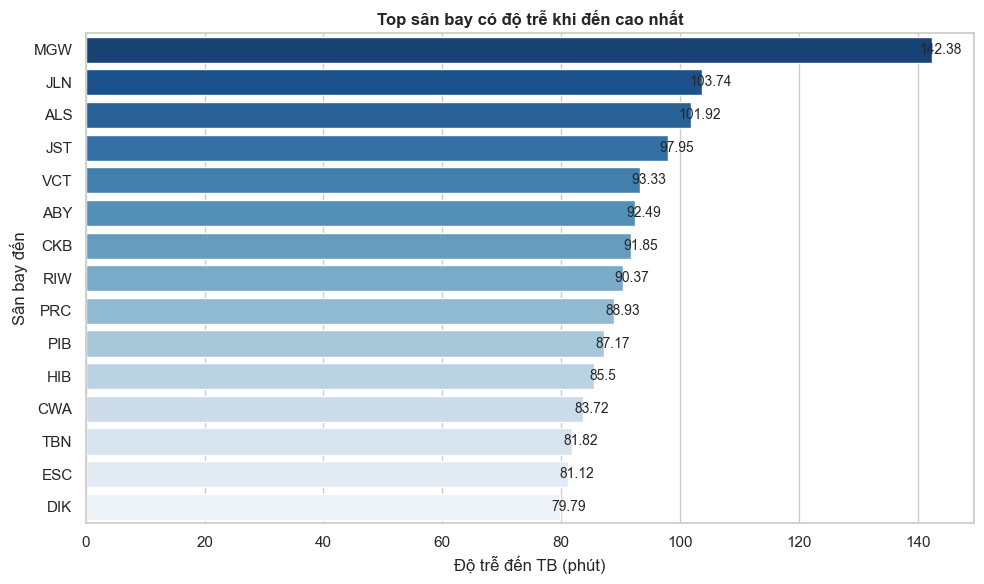

In [24]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=dest_arr_top15,
    x="Độ trễ đến TB (phút)",
    y="Sân bay đến",
    palette="Blues_r"
)

for i, v in enumerate(dest_arr_top15["Độ trễ đến TB (phút)"]):
    ax.text(v + 1.5, i, f"{v}", ha='center', va='center', fontsize=10)
    
plt.title("Top sân bay có độ trễ khi đến cao nhất", weight='bold')

plt.tight_layout()
plt.savefig("delay_analysis/dest_arr_delay.png", dpi=300)
plt.show()

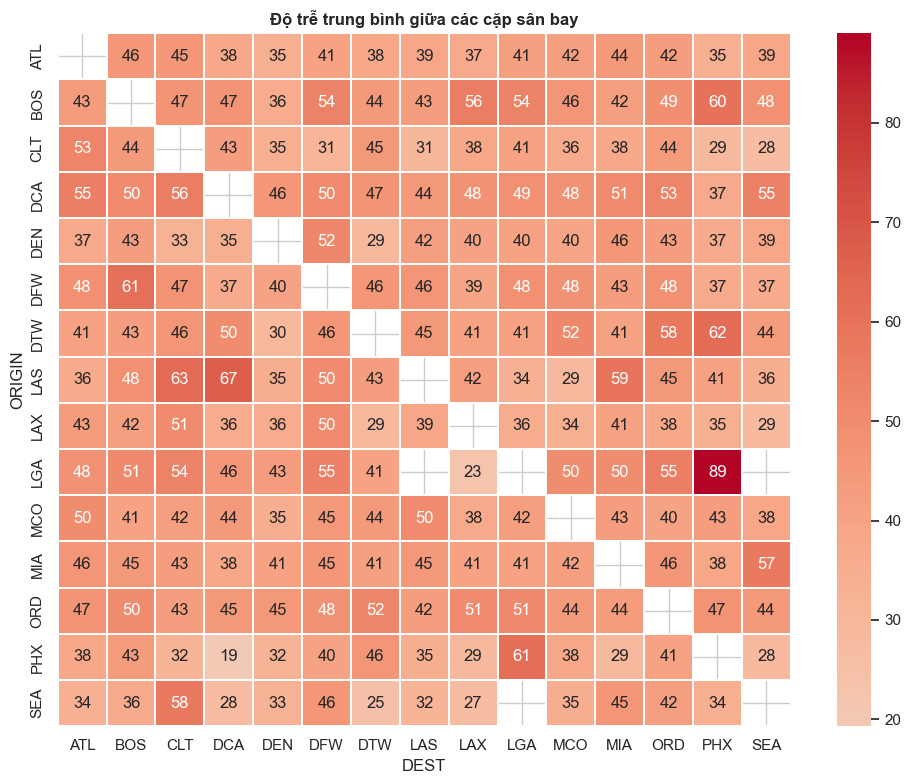

In [25]:
top_airports = df_delay["ORIGIN"].value_counts().head(15).index

heatmap_data = df_delay[
    df_delay["ORIGIN"].isin(top_airports) 
    & df_delay["DEST"].isin(top_airports)
]

pivot_airport = heatmap_data.pivot_table(
    index="ORIGIN",
    columns="DEST",
    values="ARR_DELAY_NEW",
    aggfunc="mean"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_airport,
    cmap="coolwarm",
    linewidths=0.3,
    center=0,
    annot=True,
)

plt.title("Độ trễ trung bình giữa các cặp sân bay", weight='bold')

plt.tight_layout()
plt.savefig("delay_analysis/airport_origin_destination.png", dpi=300)
plt.show()

3. Theo khoảng cách

In [26]:
distance_table = df_delay.groupby(["DISTANCE_GROUP"])["ARR_DELAY_NEW"].mean().reset_index()

distance_table.rename(columns={
    "DISTANCE_GROUP": "Nhóm khoảng cách",
    "ARR_DELAY_NEW": "Độ trễ trung bình"
}, inplace=True)

distance_table["Độ trễ trung bình"] = distance_table["Độ trễ trung bình"].astype(float).round(2)

distance_table

,Nhóm khoảng cách,Độ trễ trung bình
0,1,44.41
1,2,43.94
2,3,43.90
3,4,42.24
4,5,43.77
5,6,40.98
6,7,42.53
7,8,37.70
8,9,41.47
9,10,39.68


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18636\2072754634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


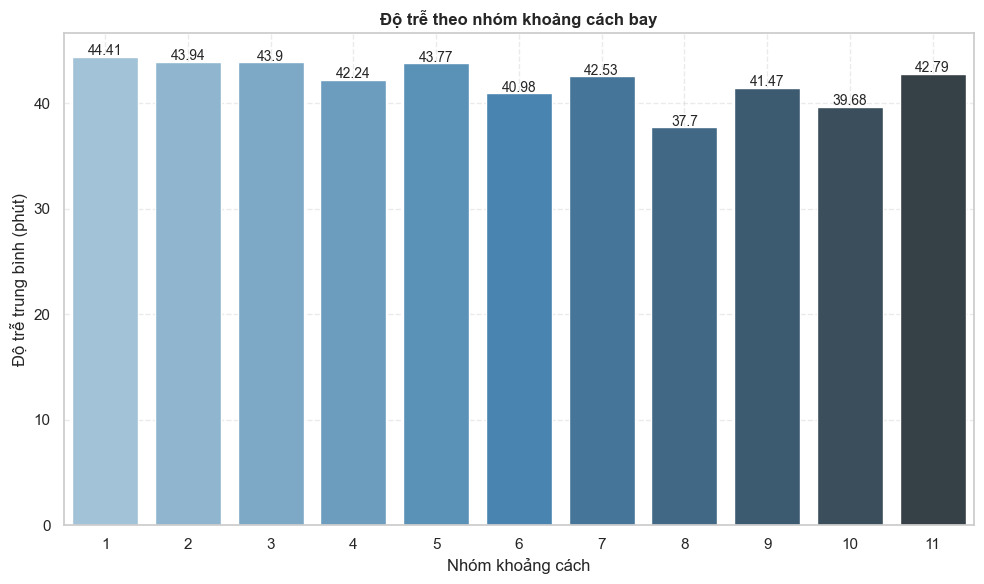

In [27]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=distance_table,
    x="Nhóm khoảng cách",
    y="Độ trễ trung bình",
    palette="Blues_d"
)

for i, v in enumerate(distance_table["Độ trễ trung bình"]):
    ax.text(i, v + 0.5, f"{v}", ha='center', va='center', fontsize=10)

plt.title("Độ trễ theo nhóm khoảng cách bay", weight='bold')
plt.xlabel("Nhóm khoảng cách")
plt.ylabel("Độ trễ trung bình (phút)")

plt.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("delay_analysis/distance_delay.png", dpi=300)
plt.show()

Phần 4: Phân rã nguyên nhân
- Tổng quan nguyên nhân trễ
- Phân tích sâu từng nguyên nhân
- Mối tương quan giữa các nguyên nhân và các yếu tố

1. Tổng quan nguyên nhân trễ

In [28]:
# Mapping tiếng Việt
cause_mapping = {
    "CARRIER_DELAY": "Trễ do hãng bay",
    "WEATHER_DELAY": "Trễ do thời tiết",
    "NAS_DELAY": "Trễ do hệ thống (NAS)",
    "SECURITY_DELAY": "Trễ do an ninh",
    "LATE_AIRCRAFT_DELAY": "Trễ do máy bay đến muộn"
}

# Màu consistent
cause_colors = {
    "Trễ do hãng bay": "#4E79A7",
    "Trễ do thời tiết": "#59A14F",
    "Trễ do hệ thống (NAS)": "#F28E2B",
    "Trễ do an ninh": "#E15759",
    "Trễ do máy bay đến muộn": "#B07AA1"
}

# Thứ tự hiển thị
cause_order = [
    "Trễ do máy bay đến muộn",
    "Trễ do hãng bay",
    "Trễ do hệ thống (NAS)",
    "Trễ do thời tiết",
    "Trễ do an ninh"
]

delay_cols = list(cause_mapping.keys())

In [29]:
total_delay = df_delay[delay_cols].sum().reset_index()
total_delay.columns = ["Nguyên nhân", "Tổng phút trễ"]

# Map tiếng Việt
total_delay["Nguyên nhân"] = total_delay["Nguyên nhân"].map(cause_mapping)

# % đóng góp
total_delay["Tỷ lệ (%)"] = total_delay["Tổng phút trễ"] / total_delay["Tổng phút trễ"].sum() * 100

# Sắp xếp
total_delay["Nguyên nhân"] = pd.Categorical(total_delay["Nguyên nhân"], categories=cause_order, ordered=True)
total_delay = total_delay.sort_values("Nguyên nhân")

total_delay

,Nguyên nhân,Tổng phút trễ,Tỷ lệ (%)
4,Trễ do máy bay đến muộn,11879809.0,35.442169
0,Trễ do hãng bay,12459881.0,37.172752
2,Trễ do hệ thống (NAS),6361917.0,18.980114
1,Trễ do thời tiết,2747010.0,8.195416
3,Trễ do an ninh,70240.0,0.209554


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18636\43935508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


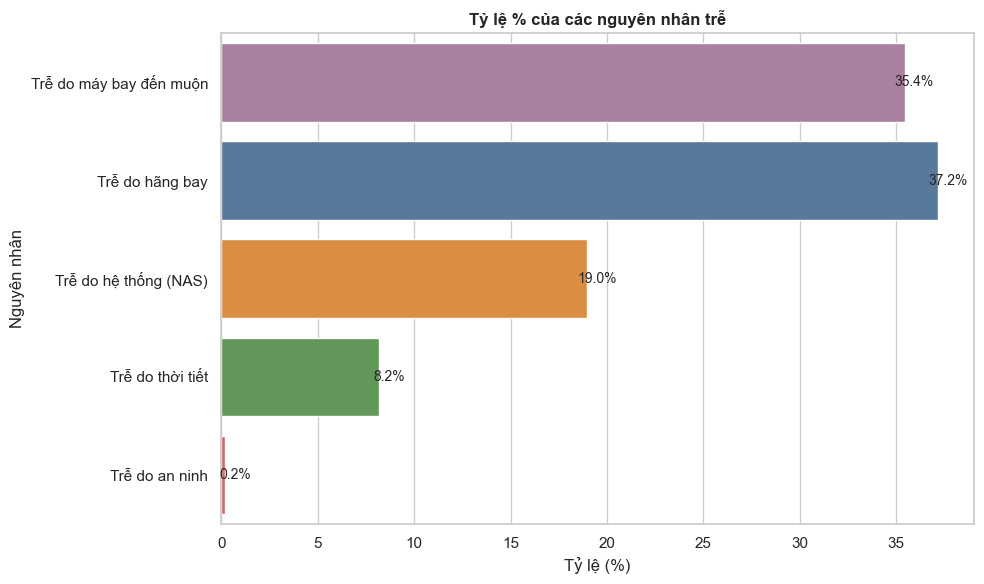

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=total_delay,
    x="Tỷ lệ (%)",
    y="Nguyên nhân",
    palette=cause_colors
)

for i, v in enumerate(total_delay["Tỷ lệ (%)"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", ha='center', va='center', fontsize=10)

plt.title("Tỷ lệ % của các nguyên nhân trễ", weight='bold')

plt.tight_layout()
plt.savefig("delay_analysis/cause_percent.png", dpi=300)
plt.show()

In [31]:
delay_year = df_delay.groupby("YEAR")[delay_cols].sum()

# % theo năm
delay_year_percent = delay_year.div(delay_year.sum(axis=1), axis=0) * 100

# rename
delay_year_percent.rename(columns=cause_mapping, inplace=True)

# reorder
delay_year_percent = delay_year_percent[cause_order]

delay_year_percent

,Trễ do máy bay đến muộn,Trễ do hãng bay,Trễ do hệ thống (NAS),Trễ do thời tiết,Trễ do an ninh
YEAR,,,,,
2021,23.162352,41.123409,25.384251,9.992704,0.337283
2022,33.375149,45.700588,14.755696,5.983528,0.185039
2023,37.088619,35.293789,21.094021,6.312973,0.210599
2024,38.952854,32.618950,17.923830,10.267266,0.237098
2025,34.717182,36.159103,19.899599,9.072186,0.151930


<Figure size 1000x600 with 0 Axes>

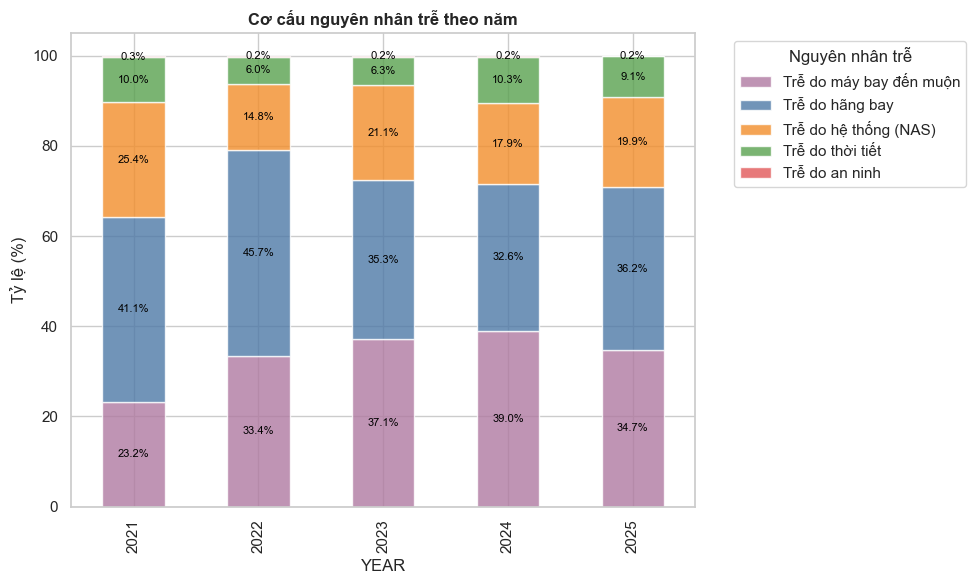

In [32]:
plt.figure(figsize=(10,6))

colors = [cause_colors[c] for c in delay_year_percent.columns]

ax = delay_year_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=colors,
    alpha=0.8
)

for i in range(len(delay_year_percent)):
    cumulative = 0
    for j, col in enumerate(delay_year_percent.columns):
        val = delay_year_percent.iloc[i, j]
        ax.text(
            i,
            cumulative + val / 2,
            f"{val:.1f}%",
            ha='center',
            va='center',
            fontsize=8,
            color='black'
        )
        cumulative += val

plt.ylabel("Tỷ lệ (%)")
plt.title("Cơ cấu nguyên nhân trễ theo năm", weight='bold')

plt.legend(title="Nguyên nhân trễ", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.savefig("delay_analysis/cause_stacked.png", dpi=300)
plt.show()

2. Phân tích sâu

2.1. Nhóm vận hành (carrier và late_aircraft)

In [33]:
# Phân tích nguyên nhân trễ nhóm vận hành theo hãng bay
carrier_op = df_delay.groupby("OP_UNIQUE_CARRIER")[["CARRIER_DELAY", "LATE_AIRCRAFT_DELAY"]].mean()

carrier_op.rename(columns=cause_mapping, inplace=True)

top_carriers = carrier_op.sum(axis=1).sort_values(ascending=False).head(10).index
carrier_op_top = carrier_op.loc[top_carriers]

carrier_op_top["Trễ do hãng bay"] = carrier_op_top["Trễ do hãng bay"].astype(float).round(2)
carrier_op_top["Trễ do máy bay đến muộn"] = carrier_op_top["Trễ do máy bay đến muộn"].astype(float).round(2)

carrier_op_top

,Trễ do hãng bay,Trễ do máy bay đến muộn
OP_UNIQUE_CARRIER,,
OO,45.48,17.88
OH,24.41,37.36
AA,28.96,32.11
YV,41.37,19.29
F9,23.90,35.04
B6,30.81,26.46
9E,25.47,28.73
G4,23.46,29.07
DL,32.55,19.39


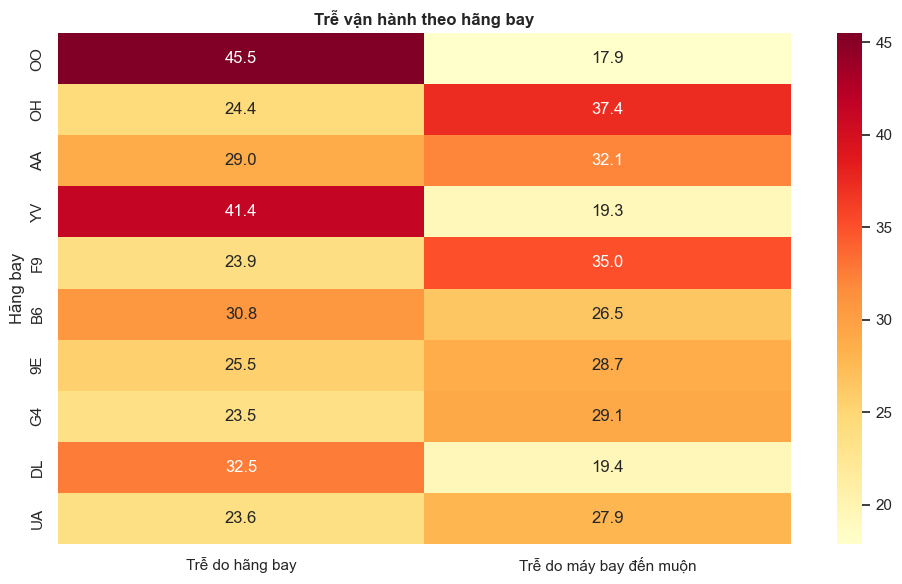

In [34]:
plt.figure(figsize=(10,6))

sns.heatmap(
    carrier_op_top,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Trễ vận hành theo hãng bay", weight='bold')
plt.ylabel("Hãng bay")

plt.tight_layout()
plt.savefig("delay_analysis/op_carrier.png", dpi=300)
plt.show()

In [35]:
# Phân tích nguyên nhân trễ nhóm vận hành theo giờ khởi hành
hour_op = df_delay.groupby("GIỜ KHỞI HÀNH")[["CARRIER_DELAY", "LATE_AIRCRAFT_DELAY"]].mean()

hour_op.rename(columns=cause_mapping, inplace=True)
hour_op["Trễ do hãng bay"] = hour_op["Trễ do hãng bay"].astype(float).round(2)
hour_op["Trễ do máy bay đến muộn"] = hour_op["Trễ do máy bay đến muộn"].astype(float).round(2)
hour_op

,Trễ do hãng bay,Trễ do máy bay đến muộn
GIỜ KHỞI HÀNH,,
0,43.80,23.51
1,35.01,23.29
2,21.04,30.71
3,16.96,28.10
4,38.94,24.09
5,54.93,12.66
6,44.82,8.75
7,37.47,8.83
8,29.76,12.94


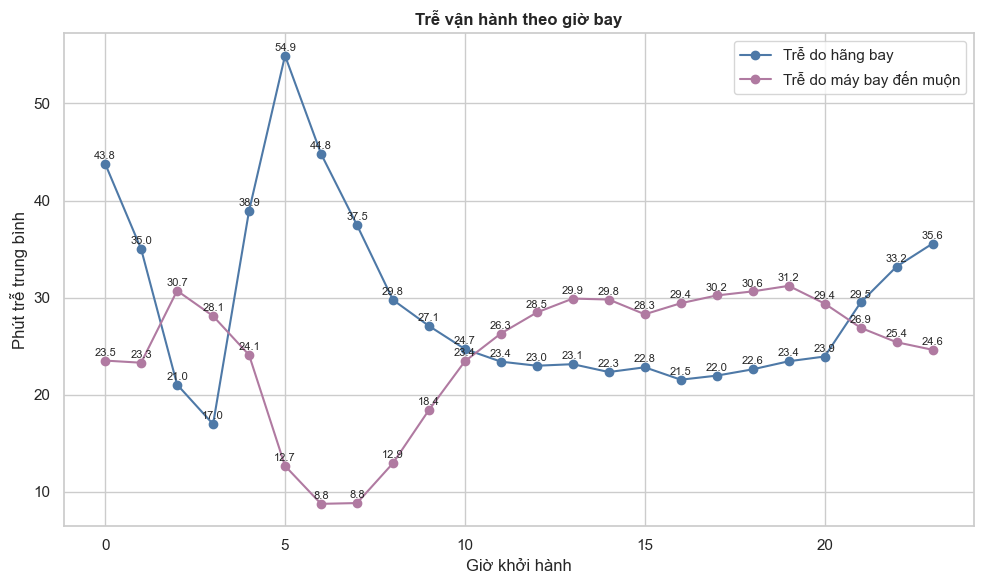

In [51]:
op_cols = ["Trễ do hãng bay", "Trễ do máy bay đến muộn"]

plt.figure(figsize=(10,6))

for col in op_cols:
    plt.plot(
        hour_op.index,
        hour_op[col],
        marker='o',
        label=col,
        color=cause_colors[col]
    )
    
    for x, y in zip(hour_op.index, hour_op[col]):
        plt.text(x, y + 0.5, f"{y:.1f}", fontsize=8, ha='center')

plt.title("Trễ vận hành theo giờ bay", weight='bold')
plt.xlabel("Giờ khởi hành")
plt.ylabel("Phút trễ trung bình")

plt.legend()

plt.tight_layout()
plt.savefig("delay_analysis/op_hour.png", dpi=300)
plt.show()

2.2. Nhóm hệ thống (nas)

In [37]:
nas_hour = df_delay.groupby("GIỜ KHỞI HÀNH")["NAS_DELAY"].mean().reset_index()
nas_hour.rename(columns={
    "GIỜ KHỞI HÀNH": "Giờ khởi hành",
    "NAS_DELAY": "Trễ do hệ thống (NAS)"
}, inplace=True)

nas_hour["Trễ do hệ thống (NAS)"] = nas_hour["Trễ do hệ thống (NAS)"].astype(float).round(2)
nas_hour

,Giờ khởi hành,Trễ do hệ thống (NAS)
0,0,10.78
1,1,11.16
2,2,7.83
3,3,13.29
4,4,12.03
5,5,19.81
6,6,20.51
7,7,20.14
8,8,17.80
9,9,14.56


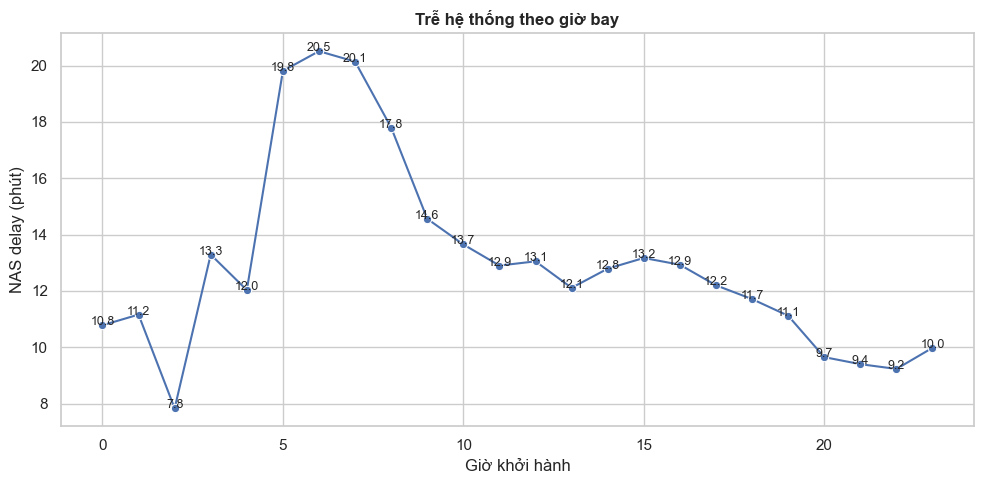

In [38]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(
    data=nas_hour,
    x="Giờ khởi hành",
    y="Trễ do hệ thống (NAS)",
    marker='o'
)

for x, y in zip(nas_hour["Giờ khởi hành"], nas_hour["Trễ do hệ thống (NAS)"]):
    ax.text(x, y, f"{y:.1f}", fontsize=9, ha='center')

plt.title("Trễ hệ thống theo giờ bay", weight='bold')
plt.xlabel("Giờ khởi hành")
plt.ylabel("NAS delay (phút)")

plt.tight_layout()
plt.savefig("delay_analysis/nas_hour.png", dpi=300)
plt.show()

In [39]:
nas_airport = df_delay.groupby("ORIGIN")["NAS_DELAY"].mean().reset_index()

nas_airport = nas_airport.sort_values("NAS_DELAY", ascending=False).head(15)

nas_airport.rename(columns={
    "ORIGIN": "Sân bay đi",
    "NAS_DELAY": "Trễ do hệ thống (NAS)"
}, inplace=True)

nas_airport["Trễ do hệ thống (NAS)"] = nas_airport["Trễ do hệ thống (NAS)"].astype(float).round(2)  

nas_airport

,Sân bay đi,Trễ do hệ thống (NAS)
70,CKB,39.83
258,PAH,38.84
228,MKG,33.33
331,SPI,29.35
166,IAG,28.69
128,FNT,27.24
256,OWB,27.00
7,ACY,26.89
34,BGR,26.88
157,HOB,26.41


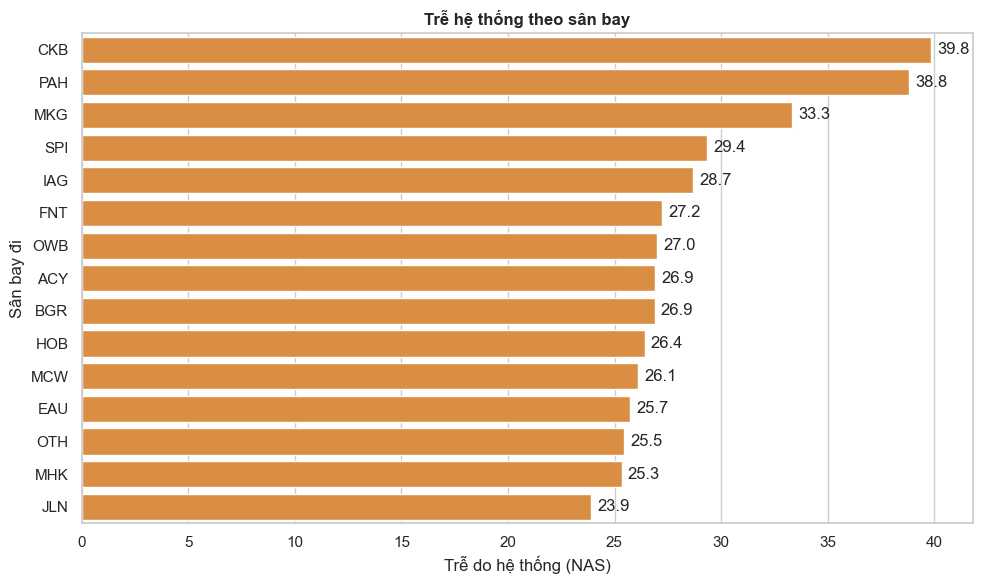

In [40]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=nas_airport,
    x="Trễ do hệ thống (NAS)",
    y="Sân bay đi",
    color="#F28E2B"
)

for i, v in enumerate(nas_airport["Trễ do hệ thống (NAS)"]):
    ax.text(v + 0.3, i, f"{v:.1f}", va='center')

plt.title("Trễ hệ thống theo sân bay", weight='bold')

plt.tight_layout()
plt.savefig("delay_analysis/nas_airport.png", dpi=300)
plt.show()

2.3. Nhóm ngoại cảnh (weather)

In [41]:
weather_state = df_delay.groupby("ORIGIN_STATE_NM")["WEATHER_DELAY"].mean().reset_index()

weather_state = weather_state.sort_values("WEATHER_DELAY", ascending=False).head(15)

weather_state.rename(columns={
    "ORIGIN_STATE_NM": "Bang",  
    "WEATHER_DELAY": "Trễ do thời tiết"
}, inplace=True)

weather_state["Trễ do thời tiết"] = weather_state["Trễ do thời tiết"].astype(float).round(2)
weather_state

,Bang,Trễ do thời tiết
41,South Dakota,21.67
33,North Dakota,18.80
3,Arkansas,18.42
52,Wyoming,16.88
50,West Virginia,16.47
25,Montana,15.13
15,Kansas,14.51
11,Idaho,13.13
14,Iowa,12.82
22,Minnesota,12.21


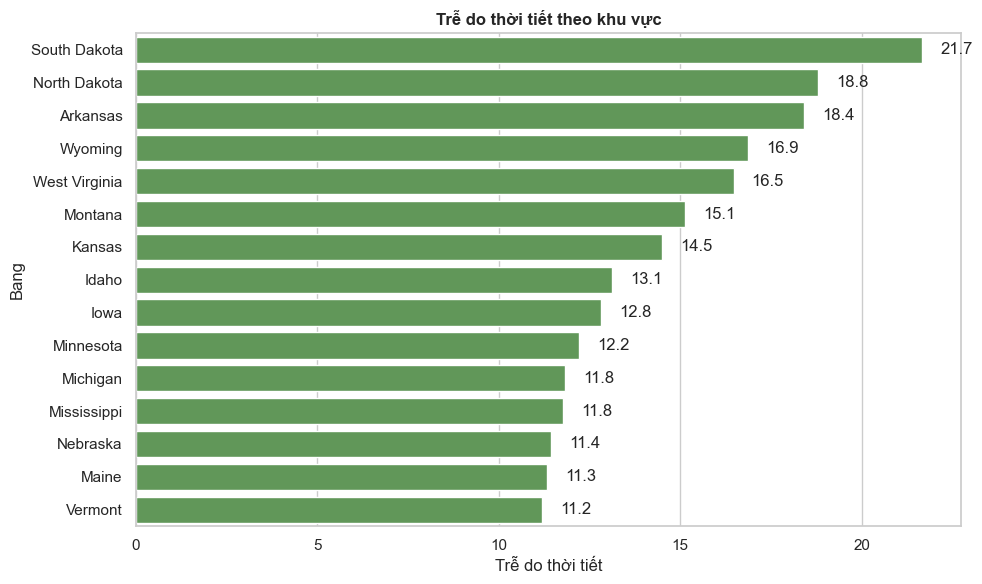

In [43]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=weather_state,
    x="Trễ do thời tiết",
    y="Bang",
    color="#59A14F"
)

for i, v in enumerate(weather_state["Trễ do thời tiết"]):
    ax.text(v + 0.5, i, f"{v:.1f}", va='center')

plt.title("Trễ do thời tiết theo khu vực", weight='bold')

plt.tight_layout()
plt.savefig("delay_analysis/weather.png", dpi=300)
plt.show()

3. Tương quan giữa các nguyên nhân và các yếu tố

In [55]:
corr_cols = [
    "ARR_DELAY_NEW",
    "DEP_DELAY_NEW",
    "DISTANCE",
    "DISTANCE_GROUP",
    "GIỜ KHỞI HÀNH",
    "DAY_OF_WEEK",
    "IS_WEEKEND",
    "DAY_OF_MONTH",
    "CARRIER_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "NAS_DELAY",
    "WEATHER_DELAY",
    "SECURITY_DELAY"
]

corr_df = df_delay[corr_cols].copy()

COLUMN_MAPPING = {
    "ARR_DELAY_NEW": "Độ trễ đến nơi",
    "DEP_DELAY_NEW": "Độ trễ khởi hành",
    "DISTANCE": "Khoảng cách",
    "DISTANCE_GROUP": "Nhóm khoảng cách",
    "GIỜ KHỞI HÀNH": "Giờ khởi hành",
    "DAY_OF_WEEK": "Ngày trong tuần",
    "IS_WEEKEND": "Là cuối tuần",
    "DAY_OF_MONTH": "Ngày trong tháng",
    "CARRIER_DELAY": "Trễ do hãng hàng không",
    "LATE_AIRCRAFT_DELAY": "Trễ do máy bay đến muộn",
    "NAS_DELAY": "Trễ do hệ thống (NAS)",
    "WEATHER_DELAY": "Trễ do thời tiết",
    "SECURITY_DELAY": "Trễ do an ninh"
}

corr_df.rename(columns=COLUMN_MAPPING, inplace=True)

corr = corr_df.corr()

corr

,Độ trễ đến nơi,Độ trễ khởi hành,Khoảng cách,Nhóm khoảng cách,Giờ khởi hành,Ngày trong tuần,Là cuối tuần,Ngày trong tháng,Trễ do hãng hàng không,Trễ do máy bay đến muộn,Trễ do hệ thống (NAS),Trễ do thời tiết,Trễ do an ninh
Độ trễ đến nơi,1.000000,0.978943,-0.010524,-0.011372,0.020568,-0.026734,-0.009324,-0.037571,0.670765,0.486198,0.176839,0.387271,0.017447
Độ trễ khởi hành,0.978943,1.000000,-0.007912,-0.008655,0.042823,-0.026069,-0.008448,-0.042459,0.676349,0.505219,0.079609,0.370985,0.019504
Khoảng cách,-0.010524,-0.007912,1.000000,0.983367,-0.025205,0.007952,0.018235,-0.025110,0.007769,-0.016893,0.019816,-0.037738,0.005497
Nhóm khoảng cách,-0.011372,-0.008655,0.983367,1.000000,-0.026002,0.008111,0.018381,-0.025624,0.006755,-0.016785,0.020629,-0.038888,0.005805
Giờ khởi hành,0.020568,0.042823,-0.025205,-0.026002,1.000000,0.023423,0.016561,-0.034959,-0.047500,0.096432,-0.085704,-0.017228,0.004510
Ngày trong tuần,-0.026734,-0.026069,0.007952,0.008111,0.023423,1.000000,0.793626,0.008210,0.001729,-0.025747,-0.033802,-0.018683,0.003222
Là cuối tuần,-0.009324,-0.008448,0.018235,0.018381,0.016561,0.793626,1.000000,-0.033046,0.009714,-0.015067,-0.031709,-0.014909,0.004735
Ngày trong tháng,-0.037571,-0.042459,-0.025110,-0.025624,-0.034959,0.008210,-0.033046,1.000000,-0.003278,-0.035609,0.002224,0.009052,-0.002821
Trễ do hãng hàng không,0.670765,0.676349,0.007769,0.006755,-0.047500,0.001729,0.009714,-0.003278,1.000000,-0.061274,-0.088340,-0.041572,-0.012289
Trễ do máy bay đến muộn,0.486198,0.505219,-0.016893,-0.016785,0.096432,-0.025747,-0.015067,-0.035609,-0.061274,1.000000,-0.098311,-0.021005,-0.007684


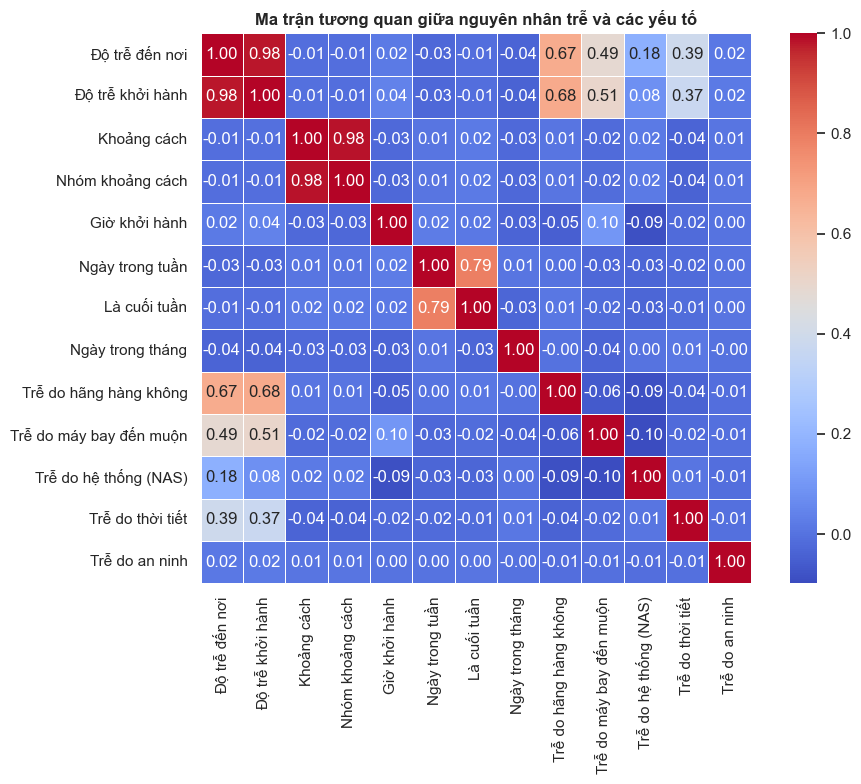

In [56]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Ma trận tương quan giữa nguyên nhân trễ và các yếu tố", weight='bold')

plt.tight_layout()
plt.savefig("delay_analysis/corr_delay_causes.png", dpi=300)
plt.show()

In [57]:
corr_target = corr["Độ trễ đến nơi"].sort_values(ascending=False)

corr_target

Độ trễ đến nơi             1.000000
Độ trễ khởi hành           0.978943
Trễ do hãng hàng không     0.670765
Trễ do máy bay đến muộn    0.486198
Trễ do thời tiết           0.387271
Trễ do hệ thống (NAS)      0.176839
Giờ khởi hành              0.020568
Trễ do an ninh             0.017447
Là cuối tuần              -0.009324
Khoảng cách               -0.010524
Nhóm khoảng cách          -0.011372
Ngày trong tuần           -0.026734
Ngày trong tháng          -0.037571
Name: Độ trễ đến nơi, dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18636\780701090.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


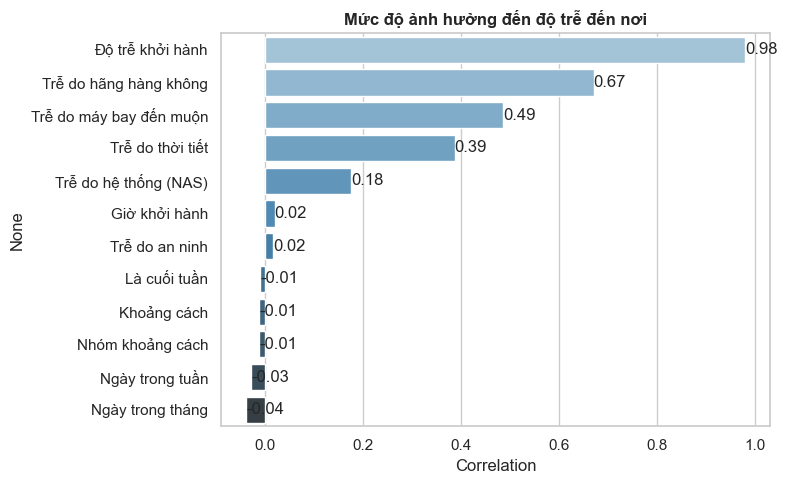

In [58]:
plt.figure(figsize=(8,5))

corr_target = corr_target.drop("Độ trễ đến nơi")

ax = sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    palette="Blues_d"
)

for i, v in enumerate(corr_target.values):
    ax.text(v, i, f"{v:.2f}", va='center')

plt.title("Mức độ ảnh hưởng đến độ trễ đến nơi", weight='bold')
plt.xlabel("Correlation")

plt.tight_layout()
plt.savefig("delay_analysis/corr_target.png", dpi=300)
plt.show()